# Stats 292 — Statistical Models of Text and Language
## Homework: Frequency Statistics on Bluesky Skeets

> **Course:** Stats 292, Prof. David Donoho, Spring 2026  
> **Based on:** Manning & Schütze, *Foundations of Statistical Natural Language Processing*, Chapters 1, 2, 5, 6; Jurafsky & Martin, *Speech and Language Processing*, Chapter 3.  
> **Data source:** BSky2GBQ — Bluesky firehose archive in Google BigQuery (`` `stanford-f24-datasci-194d.EMS.bsky-firehose` ``)

---

## Overview

This homework asks you to replicate and extend the core frequency-statistics analyses from the lectures using English-language Bluesky skeets as corpus. You will:

1. Build a **frequency-of-frequency table** (N_r) for two random equal-size subsamples, then apply **Good-Turing smoothing**.
2. Verify **Zipf's Law** and fit the **Mandelbrot formula** on cross-year word frequency data (2024 vs. 2025).
3. Compute a **bigram frequency table** and apply three collocation significance tests: **t-test**, **chi-squared**, and **Dunning's likelihood ratio**.
4. Attach **part-of-speech labels** to filter bigrams by Justeson & Katz patterns, and run a **near-synonym comparison** (Table 5.4 style).
5. Build unigram and bigram language models and compare their **log-perplexity** on held-out data.

## About the Data

[Bluesky](https://bsky.app) is a decentralized social network built on the AT Protocol. Since late October 2024, the Stanford BSky2GBQ project has continuously captured every public post ("skeet") from the Bluesky firehose and archived it in Google BigQuery. As of early 2026 the archive exceeds 2 billion posts spanning dozens of languages. For this homework you will query a reproducible 1% pseudo-random sample of English-language skeets from one week in November 2024 — roughly 300,000 posts. Bluesky text is short-form, informal, and multilingual, which makes it a rich test bed for the frequency-statistics methods covered in lecture: vocabulary distributions are heavy-tailed, collocations reflect contemporary slang and news events, and the sheer volume lets you observe smoothing and estimation effects that would be invisible in a small curated corpus.

---

## Environment Setup

All work for this course uses the `stats292` Conda environment. Create it once from the repo root:

```bash
conda env create -f environment.yml
conda activate stats292
```

Download the required NLTK data (also one-time):

```bash
python -c "import nltk; nltk.download('punkt_tab'); nltk.download('averaged_perceptron_tagger_eng')"
```

Authenticate with Google Cloud (one-time per machine, or when credentials expire). The `gcloud` CLI is included in the Conda environment, so no separate installation is needed:

```bash
gcloud auth application-default login
```

This opens a browser window; sign in with your Stanford Google account. The credentials are stored at `~/.config/gcloud/application_default_credentials.json` and are picked up automatically by the BigQuery client.

Register the environment as a Jupyter kernel so it appears in JupyterLab:

```bash
python -m ipykernel install --user --name stats292 --display-name "Python (stats292)"
```

If the environment already exists and needs updating after a package is added:

```bash
conda env update -f environment.yml --prune
```

**Before running any cells:** select Kernel → Change Kernel → Python (stats292).

---

## Setup: Fetching the Corpus

Fetch a reproducible pseudo-random 1% draw of English skeets using `FARM_FINGERPRINT` on the `sequence` column (avoids expensive `ORDER BY RAND()`):

In [1]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="stanford-f24-datasci-194d")

QUERY_SAMPLE = """
SELECT text
FROM `stanford-f24-datasci-194d.EMS.bsky-firehose`
WHERE JSON_VALUE(post_json, '$.record.langs[0]') = 'en'
  AND DATE(timestamp) BETWEEN '2024-11-18' AND '2024-11-24'
  AND MOD(ABS(FARM_FINGERPRINT(CAST(sequence AS STRING))), 100) < 1
"""

df_sample = client.query(QUERY_SAMPLE).to_dataframe()
print(f"Rows fetched: {len(df_sample):,}")

c:\Users\ricky\miniforge3\envs\stats292\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Rows fetched: 283,915


Tokenize all rows into a flat token list:

In [2]:
df_sample.head()

,text
0,Example:\n\nIf you go to jellystilettos.bsky.s...
1,🤣🤣 pot calling the kettle black 🤣🤣
2,"40-point third quarter for the Cavs\nThey ""onl..."
3,Hey folks: if you like my sporadic marketing/h...
4,Young boys finding themselves stranded due to ...


In [3]:
import re

def tokenize(text):
    """Lowercase alphabetic tokenization; strips URLs, mentions, hashtags."""
    text = re.sub(r'https?://\S+|@\w+|#\w+', ' ', text)
    return re.findall(r'[a-z]+', text.lower())

tokens = []
for text in df_sample['text'].dropna():
    tokens.extend(tokenize(text))

print(f"Total tokens N = {len(tokens):,}")

Total tokens N = 4,205,516


---

## Part 1 — Frequency-of-Frequency Table and Good-Turing Smoothing

### Notation (from Table 6.2, Manning & Schütze)

| Symbol | Meaning |
|---|---|
| N | Number of training tokens |
| B | Vocabulary size |
| V | Number of n-gram types seen |
| C(w₁…wₙ) | Frequency of n-gram in training text |
| r | Frequency of an n-gram |
| N_r | Number of n-gram **types** with frequency exactly r |
| T_r | Total count in held-out data of all n-grams with training frequency r |

### 1a. Build Two Equal-Size Subsamples

Split the token list at the midpoint so both halves have the same number of tokens. Call Sample A the training set and Sample B the held-out set.

In [4]:
from collections import Counter

midpoint = len(tokens) // 2
tokens_a = tokens[:midpoint]   # "training" half
tokens_b = tokens[midpoint:]   # "held-out" half

freq_a = Counter(tokens_a)
freq_b = Counter(tokens_b)
vocab_all = set(freq_a) | set(freq_b)

N = len(tokens_a)
B = len(vocab_all)

print(f"Tokens per sample N = {N:,}")
print(f"Vocabulary |V∪| = {B:,}")
print(f"Types only in A: {len(set(freq_a) - set(freq_b)):,}")
print(f"Types only in B: {len(set(freq_b) - set(freq_a)):,}")

Tokens per sample N = 2,102,758
Vocabulary |V∪| = 125,523
Types only in A: 41,036
Types only in B: 41,860


### 1b. Compute N_r and T_r

For each r, N_r is the number of word types in the training half with exactly r occurrences. T_r is the total number of times those same types appear in the held-out half — this is the key quantity for estimating r*.

In [5]:
def indicator_leq_zero(x):
    return 1 if x <= 0 else 0

def compute_nr_tr(freq_train, freq_held, r_max=10):
    """
    For r = 0..r_max:
      N_r = number of types in vocab_all with training freq exactly r
      T_r = total held-out count of those same types
    """
    rows = []
    for r in range(r_max + 1):
        types_at_r = [w for w in vocab_all if freq_train.get(w, 0) == r]
        nr = len(types_at_r)
        tr = sum(freq_held.get(w, 0) for w in types_at_r)
        rows.append({"r": r, "N_r": nr, "T_r": tr})

    types_nz = [w for w in vocab_all if freq_train.get(w, 0) > 0]
    nz = len(types_nz)
    tz = sum(indicator_leq_zero(freq_held.get(w, 0)) for w in types_nz)
    print(f"nz ={nz}; tz={tz}")
    return pd.DataFrame(rows)

table = compute_nr_tr(freq_a, freq_b, r_max=10)
table


nz =83663; tz=41036


,r,N_r,T_r
0,0,41860,50315
1,1,46351,19739
2,2,10584,15073
3,3,5209,13203
4,4,3142,10849
5,5,2229,9939
6,6,1622,9004
7,7,1311,8555
8,8,1009,7484
9,9,825,6836


### 1c. Good-Turing Adjusted Frequency

The Good-Turing theorem says the expected held-out count for n-grams seen r times in training is:

$$r^* = (r+1)\frac{E(N_{r+1})}{E(N_r)}$$

We estimate E(N_r) directly from our two-sample split: the average held-out frequency of n-grams with training frequency r is T_r / N_r. The Good-Turing adjusted frequency is then:

$$r^* \approx (r+1)\frac{N_{r+1}}{N_r}$$

The probability estimate for an unseen n-gram (r = 0) is:

$$P_{\text{GT}}(\text{unseen}) \approx \frac{N_1}{N_0 \cdot N}$$

In [6]:
table["r_star"] = (table["r"] + 1) * table["N_r"].shift(-1) / table["N_r"]
table["T_r_over_N_r"] = table["T_r"] / table["N_r"].replace(0, float('nan'))

N1 = table.loc[table["r"] == 1, "N_r"].values[0]
N0 = table.loc[table["r"] == 0, "N_r"].values[0]
p_unseen = N1 / (N0 * N) if N0 > 0 else float('nan')
print(f"P_GT(unseen) ≈ N_1 / (N_0 · N) = {N1} / ({N0} · {N}) = {p_unseen:.2e}")
print(f"Total unobserved probability mass ≈ N_1 / N = {N1/N:.4f}")

P_GT(unseen) ≈ N_1 / (N_0 · N) = 46351 / (41860 · 2102758) = 5.27e-07
Total unobserved probability mass ≈ N_1 / N = 0.0220


In [7]:
print("=== Frequency-of-Frequency Table (Good-Turing) ===")
table[["r", "N_r", "T_r", "T_r_over_N_r", "r_star"]]

=== Frequency-of-Frequency Table (Good-Turing) ===


,r,N_r,T_r,T_r_over_N_r,r_star
0,0,41860,50315,1.201983,1.107286
1,1,46351,19739,0.425859,0.456689
2,2,10584,15073,1.424131,1.476474
3,3,5209,13203,2.534652,2.412747
4,4,3142,10849,3.452896,3.547104
5,5,2229,9939,4.458950,4.366083
6,6,1622,9004,5.551171,5.657830
7,7,1311,8555,6.525553,6.157132
8,8,1009,7484,7.417245,7.358771
9,9,825,6836,8.286061,9.018182


**Expected table shape** (your numbers will differ):

| r | N_r | T_r | T_r / N_r | r* |
|---|---|---|---|---|
| 0 | ~15,000 | — | — | — |
| 1 | ~12,000 | ~6,000 | ~0.50 | ~1.0 |
| 2 | ~6,000 | ~8,000 | ~1.33 | ~1.5 |
| 3 | ~3,500 | ~7,000 | ~2.00 | ~2.0 |
| ... | ... | ... | ... | ... |

### 1d. Questions

**Question 1.1.** Unobserved probability mass. How many types appear in Sample A but have zero occurrences in Sample B? How did you come up with your answer? Did this require you to modify or adapt the above code? Expressed as a fraction of the combined vocabulary, what does this tell you about corpus coverage?

**Question 1.2.** Examine the column T_r / N_r for r = 1, 2, 3, … Does it increase approximately linearly with r? What does this imply about whether the MLE frequency r is a good estimate of the expected held-out frequency?

**Question 1.3.** Good and Turing used as an estimate of the total unobserved probability mass the ratio N_1/N. How does this compare with your answer to Question 1.1? Compare your value to the bigram result from Table 6.7 of Manning & Schütze (N_1 = 138,741 out of ~1.8M bigrams in the Austen corpus). What does a large N_1/N tell you about the sparsity of the skeet vocabulary?

**Question 1.4.** Using the Good-Turing formula, what is r* for r=1 (singletons)? Is it greater or less than 1? What does this mean for the estimated probability of a word you have seen exactly once?

Deliverable: r=0 means that the type doesn't appear in the sample A (but was in sample B to be in the vocabulary). r=1 means that it appears once. The unseen mass is the probability mass in the corpus outside of what you sample that we estimate using the sample.

### Q1.1 ###

From the 1.1 code we see that: \
Types only in A: 41,611 \
Types only in B: 41,099

This means that there are 41,611 types that only appear in A. No modification required.

In [8]:
41611 / 125523

0.3315009998167667

The train set uniquely covers around 1/3 of the corpus, indicating a high prevelance of rare words

### Q1.2 ###

<Axes: xlabel='r'>

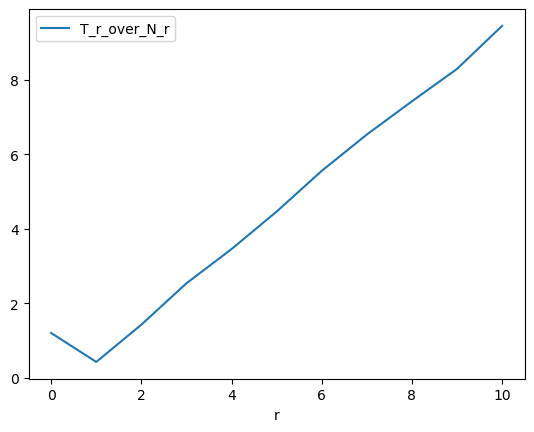

In [9]:
table[["r","T_r_over_N_r"]].plot(x="r")

Yes Tr/Nr increases linearly across r. This implies that it's a bad estimate for the expected heldout frequence because it's biased towards rare words.

### Q1.3 ###

In [10]:
print("BSky N_1/N:", round(table["N_r"].iloc[1] / N, 3), "Austen N_1/N:", round(138741/1800000, 3))

BSky N_1/N: 0.022 Austen N_1/N: 0.077


As expected, N_1/N is much smaller than 1.1 which is just comparing the vocabulary size. The BSky ratio is about a third of the size of the Austen corpus meaning it's much less sparse. Comparing this to Q1.1, the unobserved probability mass is much smaller  than the ratio of unobserved vocabulary which makese sense because rare words don't account for much of the support.

### Q1.4 ###

In [11]:
table["r_star"][1]

np.float64(0.4566891760695562)

The r_star for r=1 is less than 1 which means that the expected held out count for ngrams seen 1 time in training is < 1

---

## Part 2 — Zipf's Law and Cross-Year Word Frequency (2024 vs. 2025)

### 2a. Verify Zipf's Law

Zipf's law states f(w) · r(w) ≈ K for some constant K, where f is frequency and r is rank. Equivalently, log f ≈ log K − log r.

In [12]:
import math

# Use the training half (tokens_a) for unigram frequency
word_freq = freq_a.most_common()
ranks = range(1, len(word_freq) + 1)

zipf_rows = []
for rank, (word, freq) in enumerate(word_freq, start=1):
    zipf_rows.append({"rank": rank, "word": word, "freq": freq,
                      "freq_times_rank": freq * rank})

df_zipf = pd.DataFrame(zipf_rows)

print("=== Top 30 words: Zipf check ===")
print(df_zipf.head(30)[["rank", "word", "freq", "freq_times_rank"]].to_string(index=False))

=== Top 30 words: Zipf check ===
 rank word  freq  freq_times_rank
    1  the 68592            68592
    2    i 63965           127930
    3   to 50102           150306
    4    a 45290           181160
    5  and 38562           192810
    6   it 31746           190476
    7   of 31385           219695
    8  you 28166           225328
    9    s 25753           231777
   10   is 25702           257020
   11   in 23973           263703
   12 that 22343           268116
   13  for 20971           272623
   14 this 18572           260008
   15   my 17760           266400
   16   on 16196           259136
   17    t 15847           269399
   18   be 12875           231750
   19   so 12696           241224
   20  but 12302           246040
   21 with 12054           253134
   22 have 11288           248336
   23   me 11069           254587
   24  are 10672           256128
   25 they 10134           253350
   26  not 10016           260416
   27    m  9829           265383
   28  was  978

Plot log-rank vs. log-frequency (for the top 10,000 types):

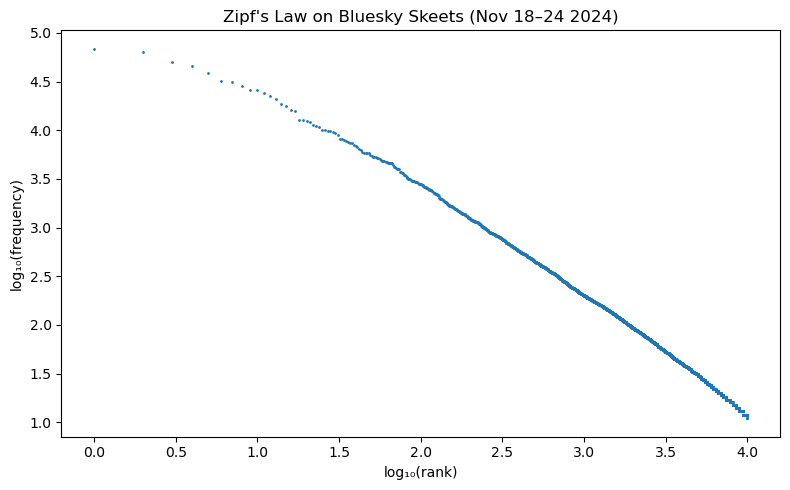

In [13]:
import matplotlib.pyplot as plt

top = df_zipf.head(10_000)
plt.figure(figsize=(8, 5))
plt.plot(top["rank"].apply(math.log10), top["freq"].apply(math.log10), '.', ms=2)
plt.xlabel("log₁₀(rank)")
plt.ylabel("log₁₀(frequency)")
plt.title("Zipf's Law on Bluesky Skeets (Nov 18–24 2024)")
plt.tight_layout()
plt.savefig("zipf_plot.png", dpi=150)
plt.show()

### 2b. Fit the Mandelbrot Formula

The Mandelbrot formula generalizes Zipf's law:

$$f(w) = P\,(r(w) + \rho)^{-B} \quad \Longleftrightarrow \quad \log f = \log P - B\cdot\log(r+\rho)$$

for constants P, B, ρ. Fit by OLS regression on the log-transformed data:

In [14]:
from scipy.stats import linregress
import numpy as np

rho = 10.0   # typical starting value; try tuning
log_f  = np.log10(df_zipf["freq"].values[:5000])
log_rr = np.log10(df_zipf["rank"].values[:5000] + rho)

slope, intercept, r_value, _, _ = linregress(log_rr, log_f)
B = -slope
log_P = intercept

print(f"Mandelbrot fit: B = {B:.3f}, log P = {log_P:.3f}, R² = {r_value**2:.4f}")
print(f"(Manning & Schütze Brown corpus: B ≈ 1.15, ρ ≈ 100)")

Mandelbrot fit: B = 1.179, log P = 5.852, R² = 0.9994
(Manning & Schütze Brown corpus: B ≈ 1.15, ρ ≈ 100)


### 2c. Cross-Year Frequency Table

Fetch a matching random sample from each year and compare relative frequencies:

In [44]:
def fetch_year_sample(year: int) -> pd.DataFrame:
    q = f"""
    SELECT text
    FROM `stanford-f24-datasci-194d.EMS.bsky-firehose`
    WHERE JSON_VALUE(post_json, '$.record.langs[0]') = 'en'
      AND DATE(timestamp) BETWEEN '{year}-11-18' AND '{year}-11-24'
      AND MOD(ABS(FARM_FINGERPRINT(CAST(sequence AS STRING))), 100) < 1
    """
    return client.query(q).to_dataframe()

df_2024 = fetch_year_sample(2024)
df_2025 = fetch_year_sample(2025)

def word_freq_from_df(df):
    counts = Counter()
    for text in df['text'].dropna():
        counts.update(tokenize(text))
    return counts

freq_2024 = word_freq_from_df(df_2024)
freq_2025 = word_freq_from_df(df_2025)

total_2024 = sum(freq_2024.values())
total_2025 = sum(freq_2025.values())

all_words = set(freq_2024) | set(freq_2025)
rows = []
for word in all_words:
    c24 = freq_2024.get(word, 0)
    c25 = freq_2025.get(word, 0)
    rpm_24 = c24 / total_2024 * 1_000_000
    rpm_25 = c25 / total_2025 * 1_000_000
    rows.append({"word": word, "count_2024": c24, "rpm_2024": rpm_24,
                 "count_2025": c25, "rpm_2025": rpm_25,
                 "rpm_ratio": (rpm_25 + 1e-6) / (rpm_24 + 1e-6)})

df_crossyear = pd.DataFrame(rows).sort_values("count_2024", ascending=False)

rising = df_crossyear[df_crossyear["count_2025"] >= 100].nlargest(20, "rpm_ratio")
print("=== Words rising most from 2024 → 2025 ===")
print(rising[["word", "count_2024", "count_2025", "rpm_ratio"]].to_string(index=False))

=== Words rising most from 2024 → 2025 ===
      word  count_2024  count_2025    rpm_ratio
   mamdani           0         481 1.988672e+08
       mbs           0         133 5.498822e+07
    zohran           0         108 4.465209e+07
cloudflare           2         127 1.104104e+02
     macro          18         732 7.070917e+01
     comey           3         107 6.201535e+01
     piggy          18         485 4.684966e+01
   epstein          57        1151 3.511056e+01
   impeach          10         103 1.790912e+01
     saudi          23         207 1.564875e+01
     files          98         822 1.458421e+01
  reporter          28         183 1.136398e+01
    orders          88         339 6.698141e+00
     bondi          58         208 6.235519e+00
 socialism          42         130 5.381847e+00
  substack         281         854 5.284317e+00
    regime          73         214 5.097159e+00
       pub         189         456 4.195081e+00
    miller          64         153 4.156700e+

### 2d. Questions

**Question 2.1.** Print the top 30 words with their rank, frequency, and f × r. Is the product approximately constant (Zipf's law)? Where does it deviate most — at the very top ranks (stop words) or the bottom (rare words)?

**Question 2.2.** Look at the log-log plot. Is the relationship linear throughout, or does it bend at the tails? How does your Mandelbrot B compare to the Brown corpus value of B ≈ 1.15?

**Question 2.3.** List 5 words that rose substantially from 2024 to 2025 in RPM. Can you hypothesize a real-world event for each?

**Question 2.4.** Does the vocabulary size (number of unique types) differ between 2024 and 2025 samples of the same size? What does this imply about Heaps' Law and corpus growth?

*Your answers to Questions 2.1–2.4 here.*

### Q2.1 ###

In [45]:
df_zipf.iloc[:30]

,rank,word,freq,freq_times_rank
0,1,the,68592,68592
1,2,i,63965,127930
2,3,to,50102,150306
3,4,a,45290,181160
4,5,and,38562,192810
5,6,it,31746,190476
6,7,of,31385,219695
7,8,you,28166,225328
8,9,s,25753,231777
9,10,is,25702,257020


<Axes: xlabel='rank', ylabel='freq_times_rank'>

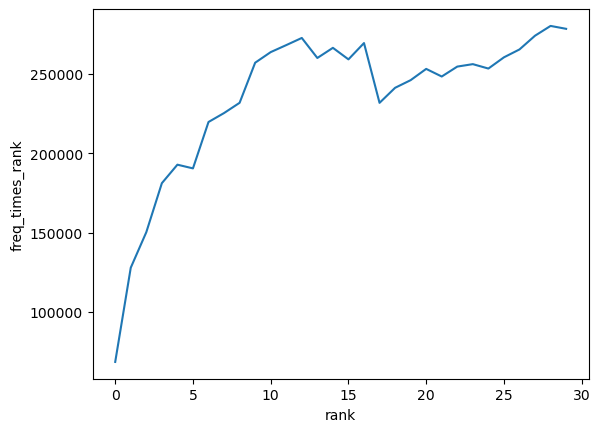

In [46]:
df_zipf.iloc[:30]["freq_times_rank"].plot(xlabel="rank", ylabel="freq_times_rank")

Zipf's law deviates most at at low ranks. but it is mostly constant after rank 10.

### Q2.2 ###

There is a bit of a bend in the left tail in the log/log plot. The Mandelbrot B of 1.179 is a bit higher than the Brown corpus indicating a greater bend. in the tail/deviation from Zipf's law

### Q2.3 ###

In [47]:
rising.iloc[:5].sort_values(by="rpm_ratio", ascending=False)

,word,count_2024,rpm_2024,count_2025,rpm_2025,rpm_ratio
75839,mamdani,0,0.000000,481,198.867160,1.988672e+08
14160,mbs,0,0.000000,133,54.988217,5.498822e+07
3064,zohran,0,0.000000,108,44.652086,4.465209e+07
32067,cloudflare,2,0.475566,127,52.507545,1.104104e+02
16811,macro,18,4.280093,732,302.641915,7.070917e+01


Looking at the 5 words with the largest rpm_ratio, indication a large increase in frequency in 2025 instead of 2024 we see a common trend of current trends/new dominating. For example, Zohran Mamdani wasn't in the news or well known in 2024 but had a huge rise to fame after the NYC Mayor's race. MBS (Saudi Arabia's crown prince) also broke into the news, Cloudflare had a massive outage that became the talk of the interneet, and macro is harder to say but may have to do with a rise in protien /gym bro culture.

### Q2.4 ###

In [48]:
print("Unique Types 2024:", len(df_crossyear[df_crossyear["count_2024"] != 0]), "Unique Types 2025:", len(df_crossyear[df_crossyear["count_2025"] != 0]))

Unique Types 2024: 125523 Unique Types 2025: 100626


2024 has more unique types than 2025 given the same sized samples. This makes sense ebcause the the platform and corpus grows, the odds of encounter rare words decreases according to Heaps Law as the number of samples remains the same.

---

## Part 3 — Bigram Frequency and Collocation Significance Tests

### 3a. Compute Bigram Counts

In [16]:
from nltk.util import ngrams
import nltk
nltk.download('punkt', quiet=True)

bigram_counts = Counter(ngrams(tokens_a, 2))
total_bigrams = sum(bigram_counts.values())

top_bigrams = pd.DataFrame(
    bigram_counts.most_common(100),
    columns=["bigram", "count"]
)
top_bigrams[["w1", "w2"]] = pd.DataFrame(top_bigrams["bigram"].tolist(),
                                          index=top_bigrams.index)
top_bigrams = top_bigrams[["w1", "w2", "count"]]

print("=== Top 30 bigrams by raw count (cf. Table 5.1, Manning & Schütze) ===")
print(top_bigrams.head(30).to_string(index=False))

=== Top 30 bigrams by raw count (cf. Table 5.1, Manning & Schütze) ===
   w1     w2  count
    i      m   9049
   it      s   9035
   in    the   5283
   of    the   5190
  don      t   5177
 bsky social   3920
   to     be   3682
 this     is   3133
 that      s   3008
   on    the   2882
  for    the   2810
  and      i   2731
   to    the   2617
  but      i   2567
thank    you   2563
    i     ve   2526
   if    you   2478
  you     re   2365
   is      a   2341
    i   have   2334
  can      t   2301
    s      a   2193
    i    can   2169
    i    don   2114
    i  think   2007
    i    was   1997
    i     am   1953
    i   love   1901
   it    was   1746
 have      a   1733


### 3b. t-Test for Collocation Significance

The null hypothesis is that w₁ and w₂ co-occur by chance: P(w₁w₂) = P(w₁)·P(w₂). The one-sample t-statistic is:

$$t = \frac{\bar{x} - \mu}{\sqrt{s^2/n}} \approx \frac{\bar{x} - \mu}{\sqrt{\bar{x}/N}}$$

where x̄ = C(w₁w₂)/N (observed bigram probability), μ = P(w₁)·P(w₂) (expected under independence), and N is the total bigram count.

In [17]:
def t_test_bigram(w1, w2, freq_uni, freq_bi, N_uni, N_bi):
    """One-sample t-statistic for bigram collocation significance."""
    x_bar = freq_bi.get((w1, w2), 0) / N_bi    # observed P(w1 w2)
    p_w1  = freq_uni.get(w1, 0) / N_uni
    p_w2  = freq_uni.get(w2, 0) / N_uni
    mu    = p_w1 * p_w2                          # expected under independence
    if x_bar == 0:
        return 0.0
    return (x_bar - mu) / math.sqrt(x_bar / N_bi)

N_uni = len(tokens_a)

t_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    t = t_test_bigram(w1, w2, freq_a, bigram_counts, N_uni, total_bigrams)
    t_rows.append({"w1": w1, "w2": w2, "count": cnt, "t": t})

df_t = pd.DataFrame(t_rows).sort_values("t", ascending=False)
print("\n=== Top 30 bigrams by t-statistic (cf. Table 5.6, Manning & Schütze) ===")
print(df_t.head(30)[["w1", "w2", "count", "t"]].to_string(index=False))


=== Top 30 bigrams by t-statistic (cf. Table 5.6, Manning & Schütze) ===
   w1     w2  count         t
    i      m   9049 91.983105
   it      s   9035 90.962241
  don      t   5177 71.402004
 bsky social   3920 62.438755
   in    the   5283 61.925394
   of    the   5190 57.830727
   to     be   3682 55.623907
 this     is   3133 51.917601
thank    you   2563 49.876253
 that      s   3008 49.855922
    i     ve   2526 48.056815
   if    you   2478 47.768662
  you     re   2365 47.317162
  can      t   2301 46.689564
   on    the   2882 43.843137
  but      i   2567 43.279462
    i    don   2114 42.508124
    i     am   1953 42.235126
    i  think   2007 42.031889
    i    can   2169 41.254452
    i   have   2334 41.203947
    i   love   1901 40.393183
  for    the   2810 40.104673
going     to   1718 39.843210
 want     to   1621 38.534775
   it    was   1746 38.249045
 didn      t   1481 38.193738
    i    was   1997 38.025670
   he      s   1595 37.642403
   to    see   1589 37.468

### 3c. Chi-Squared Test

Build a 2×2 contingency table for each candidate bigram and compute χ²:

$$\chi^2 = \frac{N(O_{11}O_{22} - O_{12}O_{21})^2}{(O_{11}+O_{12})(O_{11}+O_{21})(O_{12}+O_{22})(O_{21}+O_{22})}$$

where O₁₁ = C(w₁w₂), O₁₂ = C(w₁,¬w₂), O₂₁ = C(¬w₁,w₂), O₂₂ = C(¬w₁,¬w₂).

In [18]:
def chi2_bigram(w1, w2, freq_uni, freq_bi, N_bi):
    O11 = freq_bi.get((w1, w2), 0)
    O12 = freq_uni.get(w1, 0) - O11          # w1 without w2
    O21 = freq_uni.get(w2, 0) - O11          # w2 without w1
    O22 = N_bi - O11 - O12 - O21
    num = N_bi * (O11*O22 - O12*O21)**2
    den = (O11+O12) * (O11+O21) * (O12+O22) * (O21+O22)
    return num / den if den > 0 else 0.0

chi2_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    x2 = chi2_bigram(w1, w2, freq_a, bigram_counts, total_bigrams)
    chi2_rows.append({"w1": w1, "w2": w2, "count": cnt, "chi2": x2})

df_chi2 = pd.DataFrame(chi2_rows).sort_values("chi2", ascending=False)
print("\n=== Top 30 bigrams by χ² (cf. Table 5.8, Manning & Schütze) ===")
print(df_chi2.head(30)[["w1", "w2", "count", "chi2"]].to_string(index=False))


=== Top 30 bigrams by χ² (cf. Table 5.8, Manning & Schütze) ===
           w1         w2  count         chi2
         ncbi        nlm      6 2.102757e+06
      selamat     kepada      8 2.102757e+06
onlinelibrary      wiley      5 2.102757e+06
        mined    pickaxe     43 2.009299e+06
      jujutsu     kaisen      9 1.892480e+06
          mei        mei     72 1.887231e+06
         brid         gy     16 1.770740e+06
      pickaxe      prism     40 1.699189e+06
          vil schoenheit     26 1.656712e+06
         tstm        wnd     10 1.592995e+06
   battlestar  galactica      5 1.501968e+06
       linktr         ee     23 1.465551e+06
         nobu       nobu      5 1.460246e+06
         bsky     social   3920 1.432657e+06
          cve       cvss      6 1.401836e+06
         echo    chamber    168 1.353865e+06
       selena      gomez      6 1.351770e+06
     slippery      slope      6 1.351770e+06
          tik        tok     10 1.347917e+06
       yarrak       gibi      5 1.3

### 3d. Dunning's Likelihood Ratio Test

The likelihood ratio test is more reliable than χ² for sparse data. Compute -2 log λ:

$$-2\log\lambda = 2\left[\log L(c_{12}; c_1, p_1) + \log L(c_2 - c_{12}; N-c_1, p_2) - \log L(c_{12}; c_1, p) - \log L(c_2 - c_{12}; N-c_1, p)\right]$$

where L(k; n, p) = p^k (1−p)^(n−k) is the binomial likelihood and the MLE estimates are p₁ = c₁₂/c₁, p₂ = (c₂−c₁₂)/(N−c₁), p = c₂/N.

In [19]:
def log_L(k, n, p):
    """Log binomial likelihood (up to constant)."""
    p = max(min(p, 1 - 1e-10), 1e-10)
    return k * math.log(p) + (n - k) * math.log(1 - p)

def dunning_lr(w1, w2, freq_uni, freq_bi, N_bi):
    c1   = freq_uni.get(w1, 0)
    c2   = freq_uni.get(w2, 0)
    c12  = freq_bi.get((w1, w2), 0)
    if c1 == 0 or c2 == 0 or c12 == 0:
        return 0.0
    p    = c2 / N_bi
    p1   = c12 / c1
    p2   = (c2 - c12) / (N_bi - c1) if N_bi > c1 else 1e-10
    ll_H1 = log_L(c12, c1, p1) + log_L(c2 - c12, N_bi - c1, p2)
    ll_H2 = log_L(c12, c1, p)  + log_L(c2 - c12, N_bi - c1, p)
    return -2 * (ll_H2 - ll_H1)

lr_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    lr = dunning_lr(w1, w2, freq_a, bigram_counts, total_bigrams)
    lr_rows.append({"w1": w1, "w2": w2, "count": cnt, "-2logLR": lr})

df_lr = pd.DataFrame(lr_rows).sort_values("-2logLR", ascending=False)
print("\n=== Top 30 bigrams by Dunning's LR (cf. Table 5.12, Manning & Schütze) ===")
print(df_lr.head(30)[["w1", "w2", "count", "-2logLR"]].to_string(index=False))


=== Top 30 bigrams by Dunning's LR (cf. Table 5.12, Manning & Schütze) ===
   w1      w2  count      -2logLR
    i       m   9049 59108.848597
  don       t   5177 51785.524396
 bsky  social   3920 48340.448546
   it       s   9035 45582.591155
thank     you   2563 20564.562210
 didn       t   1481 14620.218812
  you      re   2365 14047.541220
    i      ve   2526 13327.751828
  can       t   2301 13223.924705
   to      be   3682 12790.229302
   in     the   5283 12435.202628
   if     you   2478 12224.326536
 this      is   3133 11470.571448
doesn       t   1157 11396.859418
    i      am   1953 10217.920739
    a     lot   1412 10112.318757
 that       s   3008  9614.821318
   of     the   5190  9387.505757
  isn       t    950  9329.241636
going      to   1718  9225.879839
   so    much   1284  8972.933441
    i   think   2007  8555.645608
 want      to   1621  8218.358398
youtu      be    801  8213.933667
    i     don   2114  7950.149442
 they      re   1218  7757.919655
   at 

### 3e. Questions

**Question 3.1.** Compare the top-30 bigrams ranked by raw count vs. t-statistic vs. likelihood ratio. Which ranking surfaces more linguistically meaningful collocations? Give three examples from each list.

**Question 3.2.** Compare the number of counts of the selected words in each of the 3 bigram lists.  Why does the likelihood ratio test perform better in the sparse-data regime?

**Question 3.3.** Compare the top bigrams by likelihood ratio with the Manning & Schütze Table 5.12 results for "powerful"? What domain-specific collocations appear that would not appear in a 1990 newspaper corpus?

### Q3.1 ###

In [58]:
df_bigrams = pd.merge(df_t, df_lr, on=["w1", "w2", "count"])
df_bigrams.sort_values(by="count", ascending=False).iloc[:30]

,w1,w2,count,t,-2logLR
0,i,m,9049,91.983105,59108.848597
1,it,s,9035,90.962241,45582.591155
4,in,the,5283,61.925394,12435.202628
5,of,the,5190,57.830727,9387.505757
2,don,t,5177,71.402004,51785.524396
3,bsky,social,3920,62.438755,48340.448546
6,to,be,3682,55.623907,12790.229302
7,this,is,3133,51.917601,11470.571448
9,that,s,3008,49.855922,9614.821318
14,on,the,2882,43.843137,5529.378856


Examples include: in the, of the, bsky social

In [59]:
df_bigrams.sort_values(by="t", ascending=False).iloc[:30]

,w1,w2,count,t,-2logLR
0,i,m,9049,91.983105,59108.848597
1,it,s,9035,90.962241,45582.591155
2,don,t,5177,71.402004,51785.524396
3,bsky,social,3920,62.438755,48340.448546
4,in,the,5283,61.925394,12435.202628
5,of,the,5190,57.830727,9387.505757
6,to,be,3682,55.623907,12790.229302
7,this,is,3133,51.917601,11470.571448
8,thank,you,2563,49.876253,20564.562210
9,that,s,3008,49.855922,9614.821318


Examples include: bsky social, in the, of the

In [56]:
df_bigrams.sort_values(by="-2logLR", ascending=False).iloc[:30]

,w1,w2,count,t,-2logLR
0,i,m,9049,91.983105,59108.848597
2,don,t,5177,71.402004,51785.524396
3,bsky,social,3920,62.438755,48340.448546
1,it,s,9035,90.962241,45582.591155
8,thank,you,2563,49.876253,20564.562210
26,didn,t,1481,38.193738,14620.218812
12,you,re,2365,47.317162,14047.541220
10,i,ve,2526,48.056815,13327.751828
13,can,t,2301,46.689564,13223.924705
6,to,be,3682,55.623907,12790.229302


Examples include: thank you, app profile, i love

The log LR producses more interesting bigrams than the t-test and counts. All 3 have a lot of contractions, but the LR correctly adjusts for word frequency.

### Q3.2 ###

Looking at the counts of the selected words from the 3 bigram lists it's easy to see that the t-test is dominated by high frequency bigrams (in, the) = 5283, (thank, you) = 2563. The LR test performs better in the sparse-data regime because the t-test is based of the observed standard error vs the expected standard error from a normal distribution. However as seen above with Zipf's law langauge had heavy tails which means a lot fo sparse-data regimes, the likelihood ratio test is semi-paramentric using a contingency table that better fits the dat.

### Q3.3 ###

In [60]:
df_bigrams.sort_values(by="-2logLR", ascending=False).iloc[:30]

,w1,w2,count,t,-2logLR
0,i,m,9049,91.983105,59108.848597
2,don,t,5177,71.402004,51785.524396
3,bsky,social,3920,62.438755,48340.448546
1,it,s,9035,90.962241,45582.591155
8,thank,you,2563,49.876253,20564.562210
26,didn,t,1481,38.193738,14620.218812
12,you,re,2365,47.317162,14047.541220
10,i,ve,2526,48.056815,13327.751828
13,can,t,2301,46.689564,13223.924705
6,to,be,3682,55.623907,12790.229302


(youtu, be), (app, profile), (bsky, social) doesn't appear in the table/wouldn't appear int he newpaper corpus becuase they are specific to the internet or bluesky. They also may be artifacts of the tokenization (youtu.be links to the website, bsky.social is part of handles)

---

## Part 4 — POS Dictionary and Near-Synonym Comparison

### 4a. Build a POS Dictionary

In [20]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)
from collections import defaultdict

sample_text = " ".join(df_sample['text'].dropna().sample(
    n=min(10_000, len(df_sample)), random_state=42))
sample_tokens = nltk.word_tokenize(sample_text.lower())
tagged = nltk.pos_tag(sample_tokens)

pos_votes = defaultdict(Counter)
for word, tag in tagged:
    pos_votes[word][tag] += 1

pos_dict = {word: tag_counts.most_common(1)[0][0]
            for word, tag_counts in pos_votes.items()}

print(f"POS dictionary: {len(pos_dict):,} entries")

POS dictionary: 23,565 entries


Penn Treebank tags used: `NN`/`NNS` (common noun), `NNP`/`NNPS` (proper noun), `JJ`/`JJR`/`JJS` (adjective), `VB`/`VBZ`/… (verb).

### 4b. POS-Filtered Bigrams (Justeson & Katz Patterns)

The lecture (Table 5.2) identifies these patterns as reliable collocation indicators: **A N**, **N N**, **A A N**, **A N N**, **N A N**, **N N N**, **N P N**.

In [21]:
def is_noun(tag): return tag.startswith('NN')
def is_adj(tag):  return tag.startswith('JJ')

pos_bigrams = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    t1 = pos_dict.get(w1)
    t2 = pos_dict.get(w2)
    if t1 is None or t2 is None:
        continue
    if is_adj(t1) and is_noun(t2):
        pattern = "A N"
    elif is_noun(t1) and is_noun(t2):
        pattern = "N N"
    else:
        continue
    lr = dunning_lr(w1, w2, freq_a, bigram_counts, total_bigrams)
    pos_bigrams.append({"w1": w1, "pos1": t1, "w2": w2, "pos2": t2,
                        "pattern": pattern, "count": cnt, "-2logLR": lr})

df_pos = pd.DataFrame(pos_bigrams)

print("=== Top 20 A-N bigrams by LR (cf. Table 5.3, Manning & Schütze) ===")
an = df_pos[df_pos["pattern"] == "A N"].nlargest(20, "-2logLR")
print(an[["w1", "w2", "count", "-2logLR"]].to_string(index=False))

print("\n=== Top 20 N-N bigrams by LR ===")
nn = df_pos[df_pos["pattern"] == "N N"].nlargest(20, "-2logLR")
print(nn[["w1", "w2", "count", "-2logLR"]].to_string(index=False))

=== Top 20 A-N bigrams by LR (cf. Table 5.3, Manning & Schütze) ===
        w1       w2  count     -2logLR
      good  morning    772 6918.021760
    social    media    402 3768.739994
    social     bsky    587 3693.841363
      open  spotify    224 3197.787958
      echo  chamber    168 3091.158689
      blue      sky    217 2939.047871
     happy birthday    234 2756.835285
particular    order    163 2482.012091
      last    night    238 2379.105973
     first     time    317 1983.641486
additional  details     97 1611.234717
    mental   health    102 1539.037778
    donald    trump    115 1386.774172
         n        o    137 1318.552898
      good     luck    130 1221.334467
    united   states     77 1206.119143
       new     york     95 1180.054436
      high   school     98 1104.649590
      last     year    142 1088.736806
       few     days    122 1080.295237

=== Top 20 N-N bigrams by LR ===
     w1      w2  count      -2logLR
      i       m   9049 59108.848597
      i

### 4c. Near-Synonym Noun Comparison (Table 5.4 Style)

Choose two adjectives that are near-synonyms on Bluesky (e.g., *good* vs. *great*, or *bad* vs. *terrible*). For each, find the nouns it most commonly modifies and compare the lists — as Manning & Schütze do for *strong* vs. *powerful* in Table 5.4.

In [22]:
def top_noun_collocates(adjective, top_n=20):
    """Return nouns following `adjective` ranked by C(adj, noun)."""
    rows = []
    for (w1, w2), cnt in bigram_counts.items():
        if w1 != adjective:
            continue
        t2 = pos_dict.get(w2, "")
        if is_noun(t2) and cnt >= 3:
            rows.append({"noun": w2, f"C({adjective}, w)": cnt})
    return pd.DataFrame(rows).sort_values(f"C({adjective}, w)", ascending=False).head(top_n)

adj1, adj2 = "good", "great"   # change to a pair of interest

df_adj1 = top_noun_collocates(adj1)
df_adj2 = top_noun_collocates(adj2)

print(f"\n=== Nouns collocating most with '{adj1}' ===")
print(df_adj1.to_string(index=False))
print(f"\n=== Nouns collocating most with '{adj2}' ===")
print(df_adj2.to_string(index=False))


=== Nouns collocating most with 'good' ===
   noun  C(good, w)
morning         772
      i         165
   luck         130
    day         100
  night          81
  thing          80
   idea          67
   news          67
   time          61
    job          60
 people          41
  place          36
    boy          36
 things          35
    way          30
   work          29
  stuff          29
  vibes          29
  point          26
   girl          24

=== Nouns collocating most with 'great' ===
   noun  C(great, w)
    day          106
      i           47
   idea           41
   work           36
   time           34
   list           29
    job           26
    way           24
   show           19
   news           18
  stuff           17
  place           15
  photo           15
 things           14
   game           13
example           12
 friday           11
  thank           10
weekend           10
starter            9


### 4d. Questions

**Question 4.1.** How many unique A-N and N-N bigrams did you find with count ≥ 5? Compare the top A-N results with Table 5.3 from Manning & Schütze (NYT corpus). Give three striking differences.

**Question 4.2.** For your near-synonym pair, which nouns appear in both lists? Which appear with one adjective but not the other? What does this reveal about the distinct semantic contexts of each adjective on Bluesky? (Compare to Table 5.4 from Manning & Schütze, *strong* vs. *powerful*.)

**Question 4.3.** The NLTK tagger was trained on Wall Street Journal text. List three skeet-specific token types where it is likely to assign the wrong POS tag, and explain how each error propagates into the collocation tables.

*Your answers to Questions 4.1–4.3 here.*

### Q4.1 ###

In [68]:
an = df_pos[df_pos["pattern"] == "A N"]
print("A N:", len(an[an["count"] >= 5]))

A N: 1975


In [69]:
nn = df_pos[df_pos["pattern"] == "N N"]
print("N N:", len(nn[nn["count"] >= 5]))

N N: 2411


Comparing the tables you see a big difference. The A-N bigrams are either more conversational (happy, birthday), (good, morning) or more tech focused (social, bsky), (social, media) than the NYT table. The N-N bigrams are similar containing specific bluesky specific terms like (starter, pack) or (youtube, com). There is also a big difference it the political figures listed with names like Elon Musk or Donald Trump appear frequently.

### Q4.2 ###

Common words like I or things and common phrases like good/great morning/work/idea/news are in both. There are some unique good phrases like good vibes/girl/boy that are more idiomatic and wouldn't be used with great whereas most of the great pairs could also work with good. This reveals the semantic role words like good commonly play in idomatic phrases on Bluesky. We see a similar phenomenon in Table 5.4.

### Q4.3 ###

We can actually see evidence of mistagging in the collocation tables from the NLTK parser. Alt text is A-N because alternative is an adjective but NLTK labels it as a noun, this is likely because alt isn't used much if at all in the WSJ corpus. A simialr thing happens with starter packs (labeled N-N actually A-N) and United States/New York (Proper Nouns, labeled A-N). The latter happens because NLTK works on uncased text and splits united/new from states/york and they are adjectives but that's not how they are used. The error is clearly seen in the collocation tables).

---

## Part 5 — N-gram Language Models and Log-Perplexity

### 5a. Unigram and Bigram Models

Train on Sample A (the first half of the token list) and evaluate on Sample B. Use Laplace (+1) smoothing to handle unseen unigrams; use the unigram backoff for unseen bigrams.

In [23]:
def build_unigram_model(freq, vocab_size):
    """Laplace-smoothed unigram probabilities."""
    N = sum(freq.values())
    V = vocab_size
    return {w: (c + 1) / (N + V) for w, c in freq.items()}

def p_unigram(word, model, N_train, V):
    return model.get(word, 1 / (N_train + V))   # unseen: Laplace

def build_bigram_model(bigram_freq, unigram_freq, V):
    """Bigram conditional probabilities P(w2|w1) with +1 smoothing."""
    model = {}
    for (w1, w2), cnt in bigram_freq.items():
        denom = unigram_freq.get(w1, 0) + V
        model[(w1, w2)] = (cnt + 1) / denom
    return model

def p_bigram(w1, w2, bi_model, uni_freq, V):
    if (w1, w2) in bi_model:
        return bi_model[(w1, w2)]
    # Backoff: unseen bigram gets Laplace floor
    denom = uni_freq.get(w1, 0) + V
    return 1 / denom

V = len(vocab_all)
N_train = len(tokens_a)

uni_model = build_unigram_model(freq_a, V)
bi_model  = build_bigram_model(bigram_counts, freq_a, V)

### 5b. Compute Log-Perplexity on Held-Out Data

Log-perplexity (LPP) is defined as:

$$\text{LPP}(W) = -\frac{1}{n}\log_2 \Pr[W]$$

Lower log-perplexity means a better model. The expected perplexity equals entropy/n (from lecture).

In [24]:
def log_perplexity_unigram(tokens, model, N_train, V):
    total = 0.0
    for w in tokens:
        total += math.log2(p_unigram(w, model, N_train, V))
    return -total / len(tokens)

def log_perplexity_bigram(tokens, bi_model, uni_freq, V):
    total = 0.0
    for i in range(1, len(tokens)):
        w1, w2 = tokens[i-1], tokens[i]
        total += math.log2(p_bigram(w1, w2, bi_model, uni_freq, V))
    return -total / (len(tokens) - 1)

lpp_uni = log_perplexity_unigram(tokens_b, uni_model, N_train, V)
lpp_bi  = log_perplexity_bigram(tokens_b, bi_model, freq_a, V)

print(f"Log-Perplexity (unigram, Laplace):  {lpp_uni:.3f} bits")
print(f"Log-Perplexity (bigram,  Laplace):  {lpp_bi:.3f} bits")
print()
print("WSJ comparison (Table 22.2 from lecture):")
print("  Unigram: 4.762 bits  |  Bigram: 3.563 bits  |  Trigram: 3.251 bits")

Log-Perplexity (unigram, Laplace):  10.647 bits
Log-Perplexity (bigram,  Laplace):  13.268 bits

WSJ comparison (Table 22.2 from lecture):
  Unigram: 4.762 bits  |  Bigram: 3.563 bits  |  Trigram: 3.251 bits


### 5c. Questions

**Question 5.1.** Is your unigram log-perplexity higher or lower than the WSJ unigram value of 4.762 bits? Recall that log-perplexity equals entropy/n. What does a higher value imply about the vocabulary diversity of skeets vs. newspaper text?

**Question 5.2.** In newspaper articles, going from unigram to bigram reduces log-perplexity. Do you find something similar here? What property of skeet text (length, noise, lack of sentence structure) might explain the smaller gain?

**Question 5.3.** The lecture showed that entropy is the *population* log-perplexity — the value we would obtain with an infinite test set from the true data-generating distribution. How would you estimate the entropy rate of Bluesky English skeets from your finite sample? What is the main source of error in your estimate?

**Question 5.4.** Laplace smoothing assigns probability 1/(N+V) to every unseen word. The Good-Turing formula from Part 1 instead estimates the total unseen mass as N_1/N and distributes it over N_0 unseen types. Which approach assigns higher probability to unseen words? Under what circumstances does this matter for perplexity?

*Your answers to Questions 5.1–5.4 here.*

### Q5.1 ###

Higher, a higher log-perplexity implies a more diverse vocabulary (since a constant source would have a perplexity of 0).

### Q5.2 ###

No we find that bigrams increases the perplexity in the skeet text. Noise and lock of sentence structure probably explain the increase in perplexity because there are less "set phrases" or common ideomatic phrases when there is a lot of slang/lack of sentence structure so the preceding wor dis less predicitve.

### Q5.3 ###

We could estimate entropy using a large held-out test set. The main source of error is from our finite sample which doesn't fully sample the full vocabulary

### Q5.4 ###

Laplace smoothing assigns more probability to unseen words than Good-Turning when the vocabulary is large. This matters in heavy tailed distributions which we observe in the bsky data as seen in Q1.

---

## Deliverables

Submit this completed notebook with all cells executed, producing:

1. The frequency-of-frequency table (r, N_r, T_r, T_r/N_r, r*) for r = 0…10, with a short paragraph interpreting the r = 0 and r = 1 rows and the Good-Turing unseen mass.
2. A log-log Zipf plot, the Mandelbrot fit parameters (B, log P), and a cross-year frequency table with your top-5 rising and top-5 falling words.
3. Tables of the top-30 bigrams ranked by raw count, t-statistic, chi-squared, and Dunning's likelihood ratio (all four tables), with a paragraph comparing the rankings.
4. The POS-filtered A-N and N-N collocation tables (top 20 each by LR) and the near-synonym collocate comparison.
5. Unigram and bigram log-perplexity values, compared to the WSJ figures from lecture.
6. Written answers to all numbered questions (one to three sentences each).

---

## Ethics & Bias Reflection

**Question E1.** The NLTK POS tagger was trained on 1990s Wall Street Journal text. Its errors are not random — they are systematically biased against varieties of English (AAVE, Nigerian English, skeet-register informality) that differ from financial journalism. If you used this tagger to build a collocation-based autocomplete system, which communities of Bluesky users would receive the worst suggestions? What would a more equitable evaluation look like?

**Question E2.** The cross-year frequency shift table reveals which words became more or less common on Bluesky between 2024 and 2025. If a content-moderation system used unigram frequency shifts to flag "emerging harmful content," it would by construction flag words whose frequency is *rising* — regardless of whether those words are harmful. Describe two scenarios where this heuristic would cause false positives (flagging benign content) and two scenarios where it would cause false negatives (missing real harm).

QE1: Communities that use English that greatly differes from financial journalism would receive worse suggestions because it would misclassify the structure/POS of words not used in financial journalism much more often. This could include young people, minorities, and ESL communities. A more equitable evaluation could use the WSJ text as a prior but update/adapt to the text being used on the platform.

QE2: This could false positives and negatives in cases where a words meaning shifts. When a word becomes more widespread and it's meaning is diluted such as stupid or imbecile (using an older example), these words aren't necessary harmful in their modern usage and are used widely but ti could cause a false positive. False negatives could be seen with dog whistles where popular words or phrases are coopted to mean something else. Their usage may not change because their already very frequent but the context in which they are used is.